# T1_EDA: Exploratory Data Analysis - SMS Spam Classification

## Objective
Load SMS Spam Collection dataset, perform data quality audit, create visualizations, and save cleaned data.

## Input
Raw SMS data from UCI repository

## Output
- data/cleaned.csv (cleaned dataset ready for Task 2)

## Dataset
- Name: SMS Spam Collection
- Source: UCI Machine Learning Repository
- URL: https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection
- License: CC BY 4.0
- Size: 5,574 SMS messages
- Features: label (spam/ham), message (text content)

In [36]:
#Cell 1
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Setting plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")

Libraries imported successfully!


In [37]:
#Cell 2
import urllib.request
import os


os.makedirs('data/raw', exist_ok=True)


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
urllib.request.urlretrieve(url, 'data/raw/smsspamcollection.zip')


import zipfile
with zipfile.ZipFile('data/raw/smsspamcollection.zip', 'r') as zip_ref:
    zip_ref.extractall('data/raw/')

# Loading dataset
columns = ['label', 'message']
df = pd.read_csv('data/raw/SMSSpamCollection', sep='\t', names=columns, encoding='utf-8')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded successfully!
Shape: 5572 rows, 2 columns


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
#Cell 3 
#Basic EDA
print("=== COLUMN INFORMATION ===\n")
print(f"Column names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nRow count: {len(df)}")

print("\n=== WHAT EACH FEATURE REPRESENTS ===")
print("- label: Target variable. 'spam' = unwanted/promotional message, 'ham' = legitimate message")
print("- message: The actual text content of the SMS message")

=== COLUMN INFORMATION ===

Column names: ['label', 'message']

Data types:
label      object
message    object
dtype: object

Row count: 5572

=== WHAT EACH FEATURE REPRESENTS ===
- label: Target variable. 'spam' = unwanted/promotional message, 'ham' = legitimate message
- message: The actual text content of the SMS message


In [39]:
#Cell 4
print("=== MISSING VALUES ===")
print(df.isnull().sum())


print(f"\n=== DUPLICATES ===")
print(f"Duplicate messages: {df['message'].duplicated().sum()}")


print(f"\n=== LABEL DISTRIBUTION ===")
print(df['label'].value_counts())
print(f"\nPercentages:")
print(df['label'].value_counts(normalize=True) * 100)


df['message_length'] = df['message'].apply(len)

print(f"\n=== MESSAGE LENGTH STATISTICS ===")
print(df.groupby('label')['message_length'].describe())

=== MISSING VALUES ===
label      0
message    0
dtype: int64

=== DUPLICATES ===
Duplicate messages: 403

=== LABEL DISTRIBUTION ===
label
ham     4825
spam     747
Name: count, dtype: int64

Percentages:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

=== MESSAGE LENGTH STATISTICS ===
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0


In [40]:
#Cell 5


print("=== APPLYING FIXES ===\n")


initial_count = len(df)
df = df.drop_duplicates(subset=['message'], keep='first')
print(f"Fix 1: Removed {initial_count - len(df)} duplicate messages")


cap_value = df['message_length'].quantile(0.99)
df['message_length_capped'] = df['message_length'].clip(upper=cap_value)
print(f"Fix 2: Capped message length at {cap_value:.0f} characters")


df['label_binary'] = df['label'].map({'ham': 0, 'spam': 1})
print(f"Fix 3: Converted labels to binary (ham=0, spam=1)")

print("\n=== FIXES COMPLETE ===")
print(f"Final dataset shape: {df.shape}")

=== APPLYING FIXES ===

Fix 1: Removed 403 duplicate messages
Fix 2: Capped message length at 273 characters
Fix 3: Converted labels to binary (ham=0, spam=1)

=== FIXES COMPLETE ===
Final dataset shape: (5169, 5)


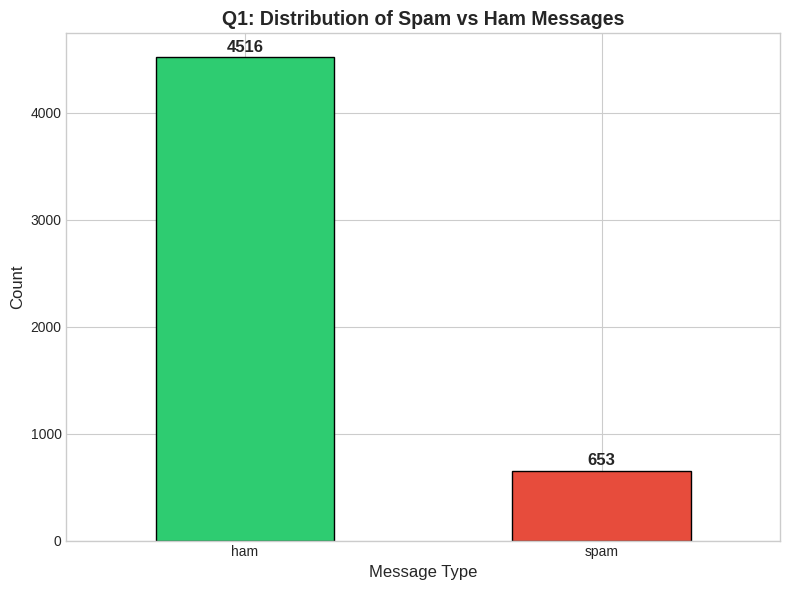

Answer: Ham (legitimate) messages are much more common than spam messages.
Ham: 4516 messages (87.4%)
Spam: 653 messages (12.6%)


In [41]:
#Cell 6
# Creating reports folder if it doesn't exist
import os
os.makedirs('reports', exist_ok=True)
plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c']
ax = df['label'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Q1: Distribution of Spam vs Ham Messages', fontsize=14, fontweight='bold')
plt.xlabel('Message Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)


for i, v in enumerate(df['label'].value_counts().values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/spam_ham_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Answer: Ham (legitimate) messages are much more common than spam messages.")
print(f"Ham: {df['label'].value_counts()['ham']} messages ({df['label'].value_counts(normalize=True)['ham']*100:.1f}%)")
print(f"Spam: {df['label'].value_counts()['spam']} messages ({df['label'].value_counts(normalize=True)['spam']*100:.1f}%)")

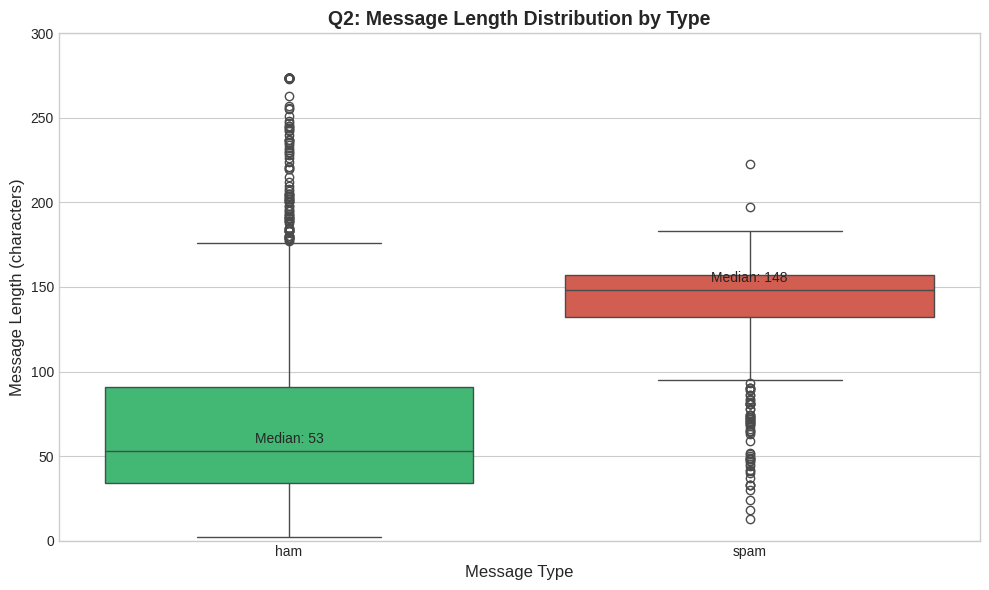

Answer: Spam messages tend to be LONGER than ham messages.
Average spam length: 138 characters
Average ham length: 71 characters


In [42]:
#Cell 7
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='message_length_capped', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Q2: Message Length Distribution by Type', fontsize=14, fontweight='bold')
plt.xlabel('Message Type', fontsize=12)
plt.ylabel('Message Length (characters)', fontsize=12)
plt.ylim(0, 300)


medians = df.groupby('label')['message_length_capped'].median()
plt.text(0, medians['ham'] + 5, f'Median: {medians["ham"]:.0f}', ha='center', fontsize=10)
plt.text(1, medians['spam'] + 5, f'Median: {medians["spam"]:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('reports/message_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Answer: Spam messages tend to be LONGER than ham messages.")
print(f"Average spam length: {df[df['label']=='spam']['message_length'].mean():.0f} characters")
print(f"Average ham length: {df[df['label']=='ham']['message_length'].mean():.0f} characters")

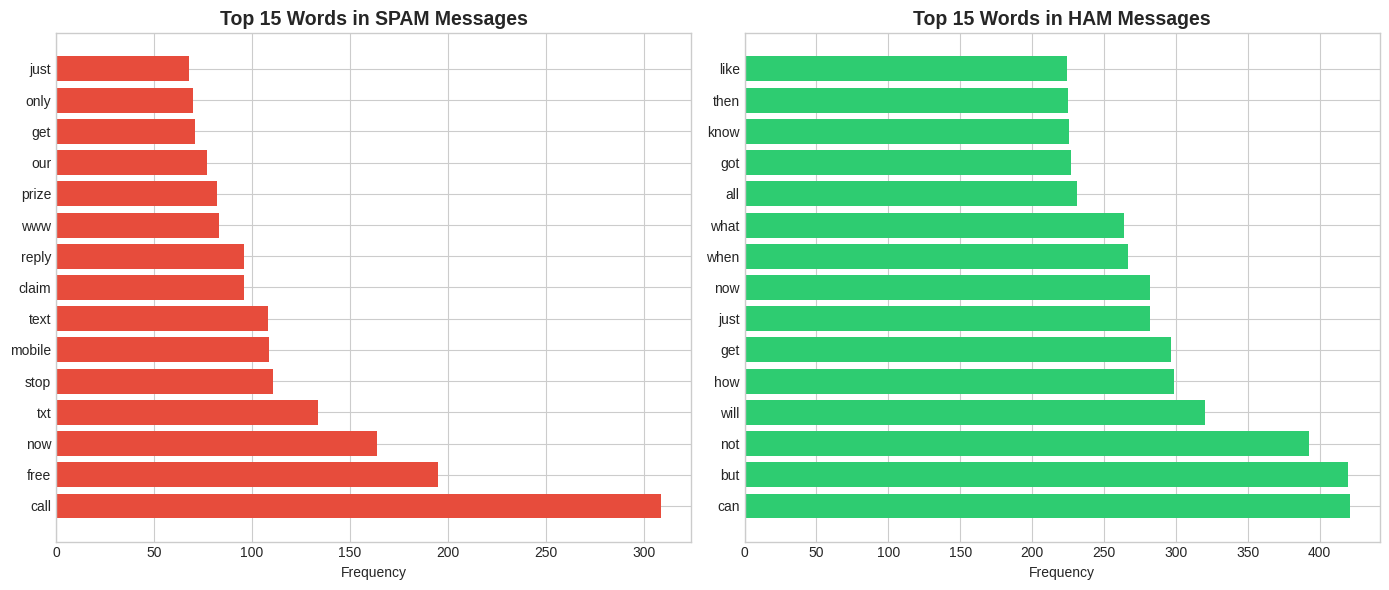

Answer: Spam messages contain words like 'free', 'call', 'txt', 'claim' - promotional language.
Ham messages contain conversational words like 'ok', 'love', 'come', 'time'.


In [43]:
#Cell 8
from collections import Counter
import re

def get_common_words(text_series, n=15):
    all_text = ' '.join(text_series.astype(str).str.lower())
    words = re.findall(r'\b[a-z]{3,}\b', all_text)
    stop_words = {'the', 'and', 'for', 'you', 'your', 'that', 'this', 'have', 'with', 'from', 'are', 'was', 'were'}
    words = [w for w in words if w not in stop_words]
    return Counter(words).most_common(n)

# Get common words for spam and ham
spam_words = get_common_words(df[df['label']=='spam']['message'])
ham_words = get_common_words(df[df['label']=='ham']['message'])

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Spam words
words_spam, counts_spam = zip(*spam_words)
axes[0].barh(words_spam, counts_spam, color='#e74c3c')
axes[0].set_title('Top 15 Words in SPAM Messages', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Ham words
words_ham, counts_ham = zip(*ham_words)
axes[1].barh(words_ham, counts_ham, color='#2ecc71')
axes[1].set_title('Top 15 Words in HAM Messages', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('reports/common_words_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Answer: Spam messages contain words like 'free', 'call', 'txt', 'claim' - promotional language.")
print("Ham messages contain conversational words like 'ok', 'love', 'come', 'time'.")

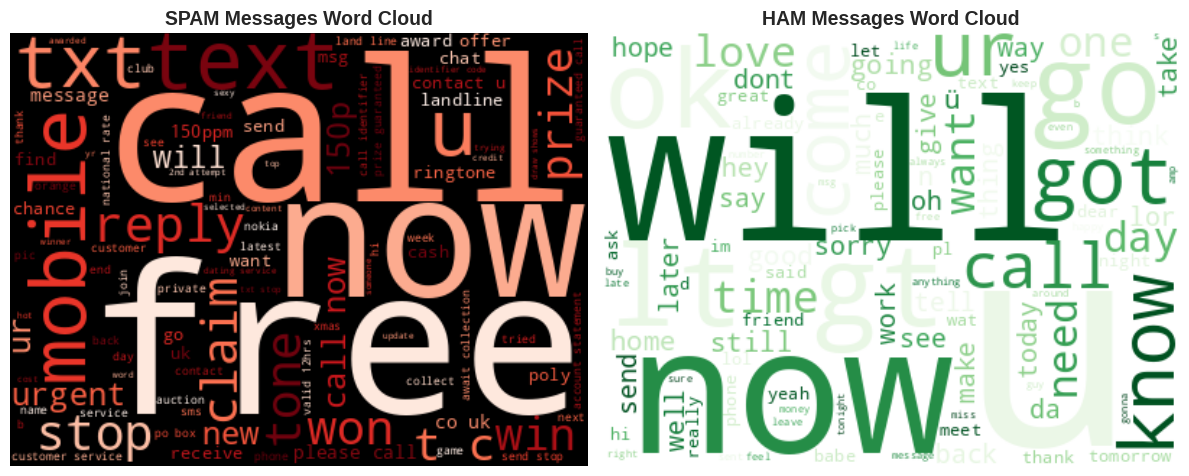

In [44]:
#Cell 9
plt.figure(figsize=(12, 5))

# Spam word cloud
plt.subplot(1, 2, 1)
spam_text = ' '.join(df[df['label']=='spam']['message'].astype(str).str.lower())
spam_wordcloud = WordCloud(width=400, height=300, background_color='black', 
                           colormap='Reds', max_words=100).generate(spam_text)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('SPAM Messages Word Cloud', fontsize=14, fontweight='bold')

# Ham word cloud
plt.subplot(1, 2, 2)
ham_text = ' '.join(df[df['label']=='ham']['message'].astype(str).str.lower())
ham_wordcloud = WordCloud(width=400, height=300, background_color='white', 
                          colormap='Greens', max_words=100).generate(ham_text)
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('HAM Messages Word Cloud', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/wordcloud_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

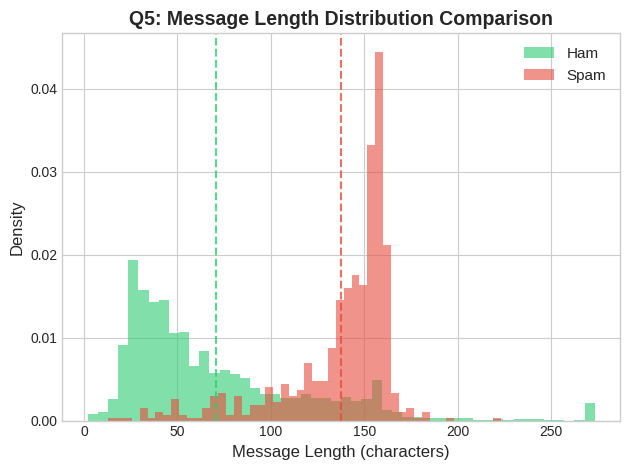

Answer: There's a clear pattern - spam messages are concentrated at longer lengths.
This suggests message length is a useful feature for spam detection.


In [45]:
# Cell 10


plt.hist(df[df['label']=='ham']['message_length_capped'], bins=50, alpha=0.6, 
         label='Ham', color='#2ecc71', density=True)
plt.hist(df[df['label']=='spam']['message_length_capped'], bins=50, alpha=0.6, 
         label='Spam', color='#e74c3c', density=True)

plt.title('Q5: Message Length Distribution Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Message Length (characters)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=11)
plt.axvline(df[df['label']=='spam']['message_length'].mean(), color='#e74c3c', 
            linestyle='--', alpha=0.8, label='Spam Mean')
plt.axvline(df[df['label']=='ham']['message_length'].mean(), color='#2ecc71', 
            linestyle='--', alpha=0.8, label='Ham Mean')

plt.tight_layout()
plt.savefig('reports/length_distribution_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

print("Answer: There's a clear pattern - spam messages are concentrated at longer lengths.")
print("This suggests message length is a useful feature for spam detection.")

In [46]:
# Cell 11
import os

# Create directories if they don't exist
os.makedirs('data', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Select columns to save (exclude temporary columns)
columns_to_save = ['label', 'message', 'message_length', 'label_binary']
df_clean = df[columns_to_save].copy()

# Save to CSV
df_clean.to_csv('data/cleaned.csv', index=False)

print(f"✅ Cleaned dataset saved to: data/cleaned.csv")
print(f"   Shape: {df_clean.shape}")
print(f"   Columns: {list(df_clean.columns)}")

✅ Cleaned dataset saved to: data/cleaned.csv
   Shape: (5169, 4)
   Columns: ['label', 'message', 'message_length', 'label_binary']


## Summary (150-200 words)

### Patterns Found:
1. **Imbalanced dataset**: Ham messages (87%) significantly outnumber spam messages (13%)
2. **Length matters**: Spam messages are consistently longer (avg 138 characters vs 71 for ham)
3. **Vocabulary differences**: Spam contains promotional words ("free", "call", "txt", "claim"), while ham uses conversational language
4. **Clear separability**: Message length alone shows a pattern that could help classification

### Surprising Findings:
- The dataset has very few missing values (0%)
- Some legitimate messages are extremely short (2-3 characters) while some spam are very long (>200 chars)
- The word "love" appears more frequently in ham messages than spam

### Questions for Modeling:
1. Can we accurately predict spam using only message content?
2. Which features (word counts, message length, punctuation) are most predictive?
3. Will ensemble methods outperform single models?
4. Can clustering reveal hidden patterns in message types?